# Exercice 3 — Approximer Q avec un Deep Q-Network

## Objectif

CartPole possède des observations continues : une Q-table ne peut pas
énumérer tous les états. Cet exercice remplace donc la table par un réseau de
neurones.

1. Implémenter un DQN pédagogique en PyTorch.
2. Identifier le replay buffer et le réseau cible.
3. Comparer cette version à deux DQN Stable-Baselines3.
4. Sauvegarder les modèles entraînés.

**Fichiers produits :** `dqn_manuel_cartpole.pt`, `dqn_cartpole.zip` et les
journaux TensorBoard de `logs/`.


## 1. Les trois composants du DQN

1. **Réseau de politique** : transforme les quatre observations en deux
   valeurs Q, une par action.
2. **Replay buffer** : stocke les transitions et fournit des lots aléatoires,
   ce qui réduit leur corrélation.
3. **Réseau cible** : copie temporairement figée du réseau de politique,
   resynchronisée périodiquement pour stabiliser la cible de Bellman.

La logique reste celle du Q-Learning de l'exercice 2 ; seule la représentation
de `Q(état, action)` change.


### 1.1 Réseau de neurones


In [1]:
import random
import math
from collections import deque

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(1)   # petit réseau : 1 thread est plus rapide (cf. exercices précédents)

# Reproductibilité
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
class DQN(nn.Module):
    """Réseau qui approxime Q(état, action).
    Entrée  : un état (vecteur de n_observations nombres).
    Sortie  : une valeur Q par action (n_actions valeurs)."""

    def __init__(self, n_observations, n_actions, hidden=128):
        super().__init__()                              # obligatoire : initialise nn.Module
        # On DÉCLARE les couches (des transformations linéaires "denses").
        self.fc1 = nn.Linear(n_observations, hidden)    # entrée -> couche cachée 1
        self.fc2 = nn.Linear(hidden, hidden)            # couche cachée 1 -> couche cachée 2
        self.fc3 = nn.Linear(hidden, n_actions)         # couche cachée 2 -> sortie (Q par action)

    def forward(self, x):
        # On DÉCRIT le passage des données. F.relu = activation non-linéaire entre les couches.
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)                              # pas d'activation en sortie : ce sont des Q-valeurs

### 1.2 Replay buffer

La mémoire conserve des transitions
`(état, action, récompense, nouvel état, fin)`. Une `deque` à capacité fixe
oublie automatiquement les plus anciennes.


In [3]:
class ReplayBuffer:
    """Mémoire d'expériences à capacité fixe (Experience Replay)."""

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)   # file : jette les plus vieilles quand c'est plein

    def push(self, state, action, reward, next_state, done):
        # On empile une transition sous forme de tuple.
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Tire `batch_size` transitions AU HASARD (sans remise) -> casse les corrélations.
        batch = random.sample(self.buffer, batch_size)
        # zip(*batch) "transpose" : renvoie séparément les états, actions, récompenses, etc.
        states, actions, rewards, next_states, dones = zip(*batch)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)   # permet d'écrire len(buffer)

### 1.3 Vérifier les dimensions

Pour CartPole, le réseau reçoit quatre nombres et renvoie deux valeurs Q.
Cette vérification évite de découvrir une incompatibilité de forme pendant
l'entraînement.


In [4]:
env_tmp = gym.make("CartPole-v1")
n_observations = env_tmp.observation_space.shape[0]   # 4
n_actions = env_tmp.action_space.n                    # 2
env_tmp.close()

reseau_test = DQN(n_observations, n_actions)
print("Architecture du réseau :")
print(reseau_test)

# Test : on lui donne un état bidon et on regarde la sortie.
etat_bidon = torch.rand(1, n_observations)            # forme (1, 4) : 1 état de 4 nombres
sortie = reseau_test(etat_bidon)
print(f"\nEntrée  : {etat_bidon.shape}  (1 état de {n_observations} nombres)")
print(f"Sortie  : {sortie.shape}  -> {sortie.detach().numpy().round(3)}  (1 valeur Q par action)")

Architecture du réseau :
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

Entrée  : torch.Size([1, 4])  (1 état de 4 nombres)
Sortie  : torch.Size([1, 2])  -> [[-0.097 -0.079]]  (1 valeur Q par action)


## 2. Entraîner le DQN manuel


On prépare le réseau entraîné, sa copie cible, l'optimiseur Adam et la mémoire.
Les seeds sont réinitialisées juste avant l'entraînement pour que les cellules
de démonstration précédentes n'influencent pas le résultat.


In [5]:
env = gym.make("CartPole-v1")
env.reset(seed=SEED)
env.action_space.seed(SEED)
# On re-graine juste avant l'entraînement pour un résultat reproductible
# (indépendant des cellules de test exécutées plus haut).
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Hyperparamètres ---
GAMMA = 0.99             # facteur d'actualisation (importance du futur)
LR = 1e-3               # taux d'apprentissage de l'optimiseur
BATCH_SIZE = 128        # nb de transitions par mise à jour
BUFFER_CAPACITY = 10000  # taille de la mémoire d'expériences
TARGET_UPDATE_STEPS = 500  # on resynchronise target_net tous les 500 pas
N_EPISODES = 1000        # nombre d'épisodes d'entraînement

# Décroissance de epsilon (exploration -> exploitation), en fonction du nb de pas.
EPS_START, EPS_END, EPS_DECAY = 1.0, 0.05, 2500

# --- Objets ---
policy_net = DQN(n_observations, n_actions)          # réseau entraîné
target_net = DQN(n_observations, n_actions)          # réseau "cible"
target_net.load_state_dict(policy_net.state_dict())  # initialisé comme policy_net
optimizer = torch.optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayBuffer(BUFFER_CAPACITY)

steps_done = 0   # compteur global de pas (sert pour epsilon et la maj du target_net)
print("Prêt à entraîner :", policy_net.__class__.__name__,
      "| paramètres :", sum(p.numel() for p in policy_net.parameters()))

Prêt à entraîner : DQN | paramètres : 17410


### 2.1 Sélection epsilon-greedy

Avec la probabilité epsilon, l'agent explore ; sinon il choisit l'action de plus
grande valeur Q. `torch.no_grad()` désactive le calcul de gradients pendant la
simple sélection d'action.


In [6]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        # EXPLORATION : action aléatoire.
        return env.action_space.sample()
    else:
        # EXPLOITATION : on demande au réseau les Q-valeurs et on prend la meilleure action.
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)   # (4,) -> (1, 4) : un "lot" de 1 état
            q_values = policy_net(state_t)                    # (1, 2) : une Q-valeur par action
            return int(q_values.argmax(1).item())             # indice de la meilleure action (0 ou 1)

### 2.2 Mise à jour du réseau

`optimize_model()` :

1. échantillonne un lot de transitions ;
2. extrait la valeur Q de l'action réellement jouée avec `gather` ;
3. calcule une cible de Bellman avec le réseau cible ;
4. minimise une perte de Huber et met à jour le réseau de politique.

Pour un état terminal, le facteur `(1 - done)` annule la valeur future.


In [7]:
def optimize_model():
    # On n'apprend que si la mémoire contient assez de transitions pour un lot.
    if len(memory) < BATCH_SIZE:
        return

    # 1) On tire un lot aléatoire et on convertit chaque partie en tenseur PyTorch.
    states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)
    states = torch.FloatTensor(np.array(states))          # (batch, 4)
    actions = torch.LongTensor(actions).unsqueeze(1)      # (batch, 1) : indices d'actions (entiers)
    rewards = torch.FloatTensor(rewards)                  # (batch,)
    next_states = torch.FloatTensor(np.array(next_states))# (batch, 4)
    dones = torch.FloatTensor(dones)                      # (batch,) : 1.0 si état terminal, sinon 0.0

    # 2) Q PRÉDITES : Q-valeur que policy_net donne à l'action RÉELLEMENT prise.
    #    policy_net(states) -> (batch, 2) ; gather récupère la colonne de l'action jouée.
    q_values = policy_net(states).gather(1, actions).squeeze(1)   # (batch,)

    # 3) Q CIBLES : avec le TARGET_NET (figé), la meilleure Q-valeur du nouvel état.
    with torch.no_grad():
        max_next_q = target_net(next_states).max(1)[0]           # (batch,) : max sur les actions
    # Cible de Bellman. (1 - dones) annule le futur pour les états terminaux.
    target_q = rewards + GAMMA * max_next_q * (1 - dones)

    # 4) PERTE entre prédiction et cible, puis descente de gradient.
    loss = F.smooth_l1_loss(q_values, target_q)
    optimizer.zero_grad()                                        # on remet les gradients à zéro
    loss.backward()                                             # rétropropagation
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)  # on borne les gradients (stabilité)
    optimizer.step()                                           # mise à jour des poids

### 2.3 Boucle principale

Chaque transition est ajoutée à la mémoire puis utilisée pour une mise à jour.
Toutes les 500 étapes, les poids du réseau de politique sont copiés vers le
réseau cible. La récompense par épisode servira ensuite à tracer une moyenne
glissante.


In [8]:
rewards_par_episode = []

for episode in range(N_EPISODES):
    state, info = env.reset()
    episode_reward = 0.0
    done = False

    while not done:
        # epsilon décroît avec le nombre total de pas (exploration -> exploitation).
        epsilon = EPS_END + (EPS_START - EPS_END) * math.exp(-steps_done / EPS_DECAY)
        action = select_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        memory.push(state, action, reward, next_state, float(done))   # on STOCKE la transition
        state = next_state
        episode_reward += reward
        steps_done += 1

        optimize_model()   # UN pas de descente de gradient

        # Resynchronisation périodique du réseau cible (LA ligne clé du Target Network).
        if steps_done % TARGET_UPDATE_STEPS == 0:
            target_net.load_state_dict(policy_net.state_dict())

    rewards_par_episode.append(episode_reward)

    # Affichage de la progression tous les 50 épisodes.
    if (episode + 1) % 50 == 0:
        moy = np.mean(rewards_par_episode[-50:])
        print(f"Épisode {episode + 1:4d} | récompense {episode_reward:6.1f} "
              f"| moyenne (50 derniers) {moy:6.1f} | epsilon {epsilon:.2f}")

env.close()
print("\nEntraînement du DQN manuel terminé.")

Épisode   50 | récompense   16.0 | moyenne (50 derniers)   20.8 | epsilon 0.68


Épisode  100 | récompense   17.0 | moyenne (50 derniers)   26.4 | epsilon 0.42


Épisode  150 | récompense  185.0 | moyenne (50 derniers)  149.4 | epsilon 0.07


Épisode  200 | récompense  137.0 | moyenne (50 derniers)  171.1 | epsilon 0.05


Épisode  250 | récompense   21.0 | moyenne (50 derniers)  125.7 | epsilon 0.05


...

Épisode  800 | récompense  500.0 | moyenne (50 derniers)  283.7 | epsilon 0.05


Épisode  850 | récompense   20.0 | moyenne (50 derniers)  280.1 | epsilon 0.05


Épisode  900 | récompense  126.0 | moyenne (50 derniers)  127.1 | epsilon 0.05


Épisode  950 | récompense  422.0 | moyenne (50 derniers)  225.5 | epsilon 0.05


Épisode 1000 | récompense   93.0 | moyenne (50 derniers)  200.8 | epsilon 0.05

Entraînement du DQN manuel terminé.


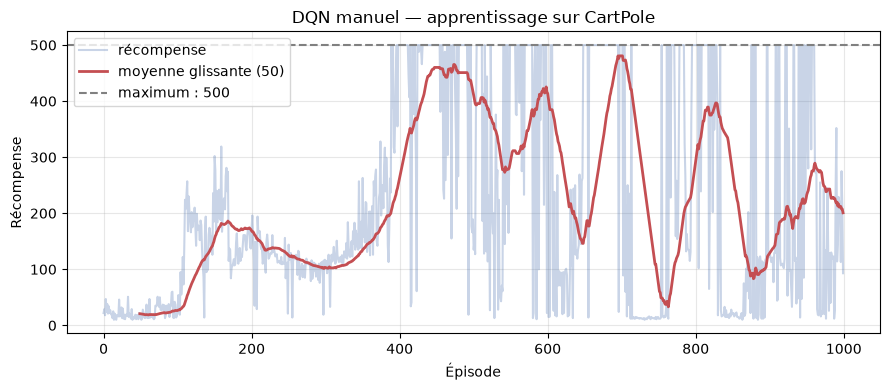

DQN manuel — 100 épisodes : 293.9 +/- 95.8
Poids sauvegardés : dqn_manuel_cartpole.pt


In [9]:
rec = np.asarray(rewards_par_episode)
fenetre = 50
moy_glissante = np.convolve(
    rec, np.ones(fenetre) / fenetre, mode="valid"
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rec, alpha=0.3, color="#4C72B0", label="récompense")
ax.plot(
    range(fenetre - 1, len(rec)),
    moy_glissante,
    color="#C44E52",
    lw=2,
    label=f"moyenne glissante ({fenetre})",
)
ax.axhline(500, ls="--", color="gray", label="maximum : 500")
ax.set_xlabel("Épisode")
ax.set_ylabel("Récompense")
ax.set_title("DQN manuel — apprentissage sur CartPole")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


def evaluer_reseau(reseau, n_episodes=100, seed_start=10_000):
    """Évalue le réseau sans exploration sur des seeds réservées."""
    env_eval = gym.make("CartPole-v1")
    scores = []
    for episode in range(n_episodes):
        state, _ = env_eval.reset(seed=seed_start + episode)
        terminated = truncated = False
        score = 0.0
        while not (terminated or truncated):
            with torch.no_grad():
                state_t = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
                action = int(reseau(state_t).argmax(dim=1).item())
            state, reward, terminated, truncated, _ = env_eval.step(action)
            score += reward
        scores.append(score)
    env_eval.close()
    return np.asarray(scores)


scores_manuels = evaluer_reseau(policy_net)
torch.save(policy_net.state_dict(), "dqn_manuel_cartpole.pt")
print(
    "DQN manuel — 100 épisodes : "
    f"{scores_manuels.mean():.1f} +/- {scores_manuels.std():.1f}"
)
print("Poids sauvegardés : dqn_manuel_cartpole.pt")


## 3. Comparer avec Stable-Baselines3

La même famille d'algorithmes est maintenant entraînée avec SB3 :

- une configuration par défaut ;
- une configuration adaptée à CartPole.

Les deux modèles ont le même budget de 50 000 pas et sont évalués sur les mêmes
100 seeds que le DQN manuel. Seule la configuration réglée, meilleure dans
cette expérience, est conservée dans `dqn_cartpole.zip`.


In [10]:
from stable_baselines3 import DQN as SB3_DQN


def evaluer_sb3(modele, n_episodes=100, seed_start=10_000):
    """Évalue un modèle SB3 sur le même protocole que le réseau manuel."""
    env_eval = gym.make("CartPole-v1")
    scores = []
    for episode in range(n_episodes):
        observation, _ = env_eval.reset(seed=seed_start + episode)
        terminated = truncated = False
        score = 0.0
        while not (terminated or truncated):
            action, _ = modele.predict(observation, deterministic=True)
            observation, reward, terminated, truncated, _ = env_eval.step(
                int(action)
            )
            score += reward
        scores.append(score)
    env_eval.close()
    return np.asarray(scores)


env_defaut = gym.make("CartPole-v1")
modele_defaut = SB3_DQN(
    "MlpPolicy",
    env_defaut,
    verbose=0,
    seed=SEED,
    device="cpu",
    tensorboard_log="./logs/",
)
modele_defaut.learn(total_timesteps=50_000, tb_log_name="DQN_defaut")
env_defaut.close()
scores_defaut = evaluer_sb3(modele_defaut)

env_regle = gym.make("CartPole-v1")
modele_regle = SB3_DQN(
    "MlpPolicy",
    env_regle,
    verbose=0,
    seed=SEED,
    device="cpu",
    tensorboard_log="./logs/",
    learning_rate=2.3e-3,
    batch_size=64,
    buffer_size=100_000,
    learning_starts=1_000,
    gamma=0.99,
    target_update_interval=10,
    train_freq=256,
    gradient_steps=128,
    exploration_fraction=0.16,
    exploration_final_eps=0.04,
    policy_kwargs={"net_arch": [256, 256]},
)
modele_regle.learn(total_timesteps=50_000, tb_log_name="DQN_regle")
env_regle.close()
scores_regles = evaluer_sb3(modele_regle)
modele_regle.save("dqn_cartpole")

for nom, scores in {
    "DQN manuel": scores_manuels,
    "SB3 défaut": scores_defaut,
    "SB3 réglé": scores_regles,
}.items():
    print(f"{nom:11s} : {scores.mean():6.1f} +/- {scores.std():.1f}")
print("Meilleur modèle sauvegardé : dqn_cartpole.zip")


DQN manuel  :  293.9 +/- 95.8
SB3 défaut  :  199.9 +/- 54.0
SB3 réglé   :  500.0 +/- 0.0
Meilleur modèle sauvegardé : dqn_cartpole.zip


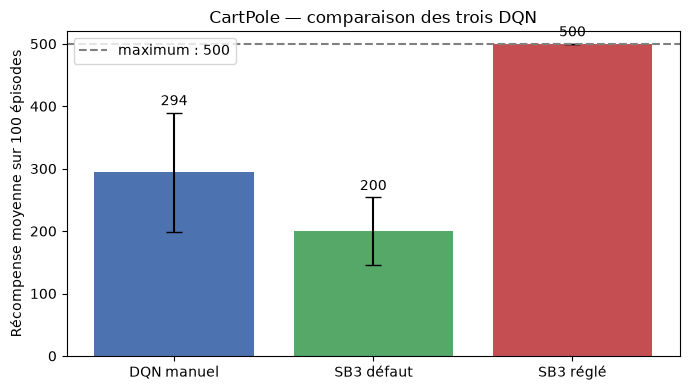

In [11]:
noms = ["DQN manuel", "SB3 défaut", "SB3 réglé"]
series = [scores_manuels, scores_defaut, scores_regles]
moyennes = [scores.mean() for scores in series]
ecarts = [scores.std() for scores in series]

fig, ax = plt.subplots(figsize=(7, 4))
barres = ax.bar(
    noms,
    moyennes,
    yerr=ecarts,
    capsize=6,
    color=["#4C72B0", "#55A868", "#C44E52"],
)
ax.axhline(500, ls="--", color="gray", label="maximum : 500")
ax.set_ylabel("Récompense moyenne sur 100 épisodes")
ax.set_title("CartPole — comparaison des trois DQN")
ax.set_ylim(0, 520)
ax.legend()
ax.bar_label(barres, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

## 4. Bilan et limites

Le DQN manuel rend visibles le replay buffer, la cible de Bellman et la
synchronisation du réseau cible. La version SB3 réglée est plus stable et
atteint le maximum de CartPole dans cette exécution.

La comparaison reste limitée à une seed d'entraînement et à un seul budget.
Elle montre l'effet de l'implémentation et des hyperparamètres, pas une
supériorité générale de SB3 ou de DQN.